In [1]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

In [2]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def linear_path(Psi, start_idx, end_idx, n_grid=10):
    return np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=27, tau=0.2):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat

def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN

# Loading processed data

In [3]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 3
EPS_DIFFUSION = 3
N_LINEAR_GRID = 40
M_LIFT = 22


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)


# Figures 1, 2, 3
Embeddings coloured by different variables

In [4]:
def plot_embedding_2d_3d(Psi, colour, colour_label, title, cmap="viridis", figsize=(14, 6), angles=(30, -60), save: str=None):
    fig = plt.figure(figsize=figsize); ax1 = fig.add_subplot(1, 2, 1)
    sort_idx = np.argsort(colour)
    sc1 = ax1.scatter(Psi[sort_idx, 0], Psi[sort_idx, 1], c=colour[sort_idx], s=20, cmap=cmap)

    ax1.set_xlabel(r"$\psi_1$"); ax1.set_ylabel(r"$\psi_2$")
    ax1.set_title(f"2D embedding coloured by {title}"); ax1.grid(alpha=0.3)
    fig.colorbar(sc1, ax=ax1, label=colour_label)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    sc2 = ax2.scatter(Psi[:, 0], Psi[:, 1], Psi[:, 2], c=colour, s=20, cmap=cmap)
    ax2.view_init(elev=angles[0], azim=angles[1])
    ax2.set_xlabel(r"$\psi_1$"); ax2.set_ylabel(r"$\psi_2$"); ax2.set_zlabel(r"$\psi_3$")
    ax2.set_title(f"3D embedding coloured by {title}"); fig.colorbar(sc2, ax=ax2, label=colour_label)

    plt.tight_layout()
    if save is None:
        plt.show()
    else:
        plt.savefig(f'{save}.pdf')


In [5]:
a = [i for i in range(743)]

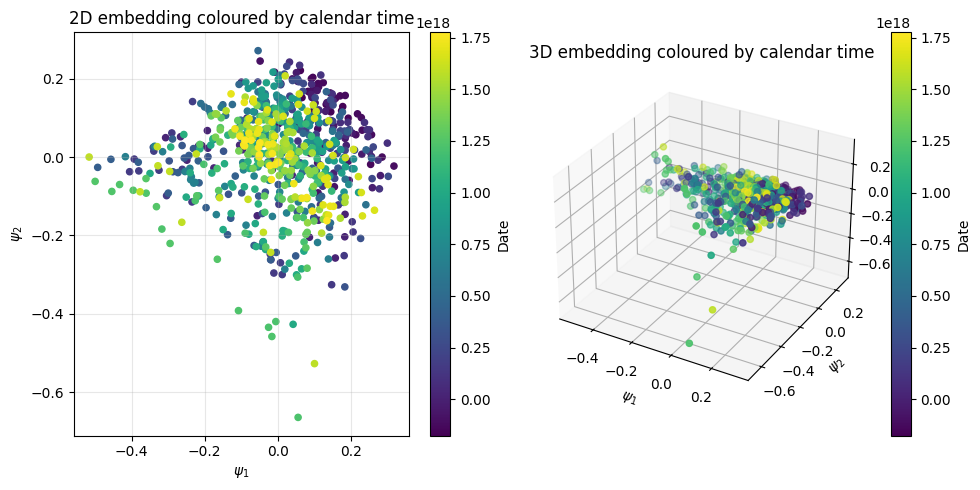

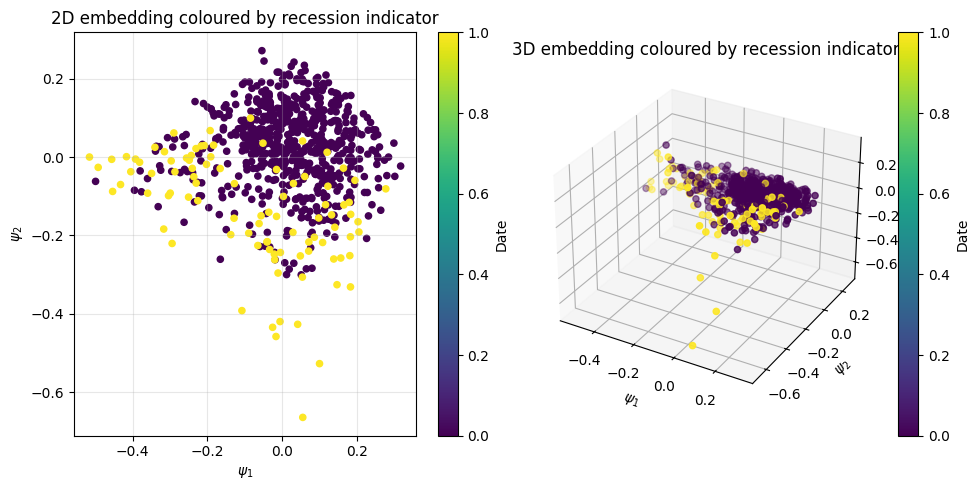

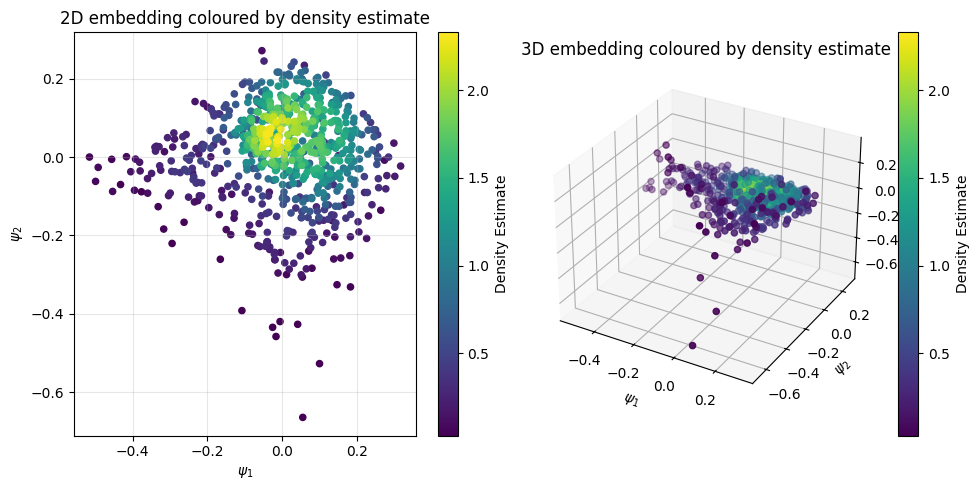

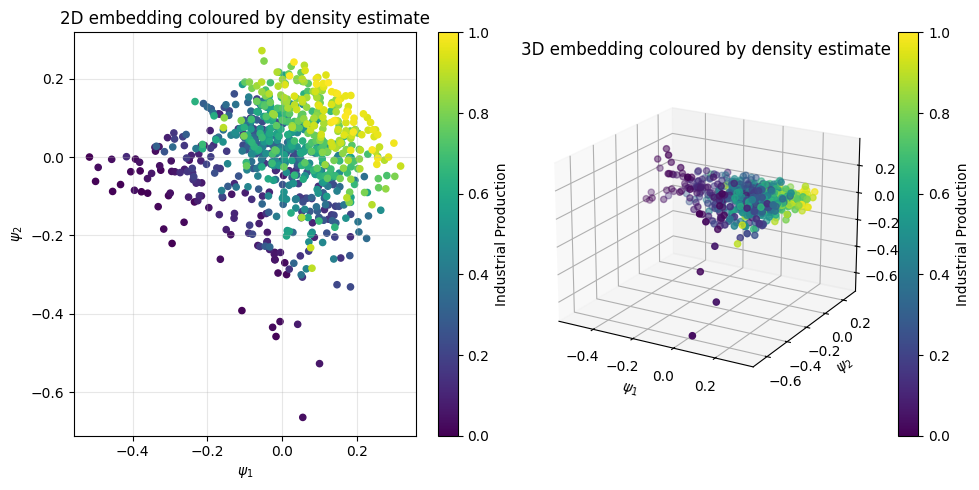

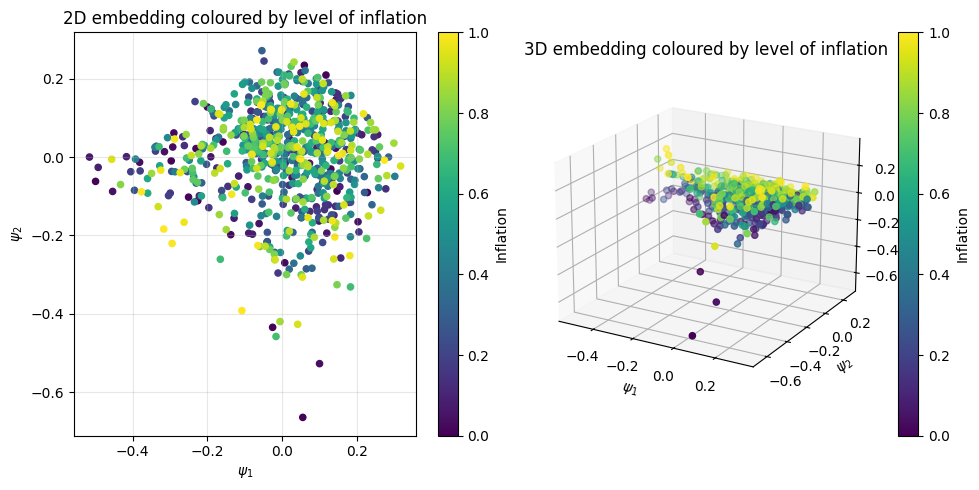

In [6]:
plot_embedding_2d_3d(Psi, colour=dates, colour_label="Date", title="calendar time", figsize=(10,5))
plot_embedding_2d_3d(Psi, colour=df["recession"].values, colour_label="Date", title="recession indicator", figsize=(10,5))
plot_embedding_2d_3d(Psi, colour=rho, colour_label="Density Estimate", title="density estimate", figsize=(10,5))
plot_embedding_2d_3d(Psi, colour=df["INDPRO"].values, colour_label="Industrial Production", title="density estimate", figsize=(10,5), angles=(20, -60))
plot_embedding_2d_3d(Psi, colour=df["CPIAUCSL"].values, colour_label="Inflation", title="level of inflation", figsize=(10,5), angles=(20, -60))



Plotting the coordinates colored by different variables shows how the 3 embedding dimensions is necessary to describe some of the coordinates. For industrial production, it seems we only need 2, but for inflation rate it's obvious that we need 3 dimensions to properly capture the variance.

# Figures 4, 5
Endpoints plotted on the embeddings

In [7]:
endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

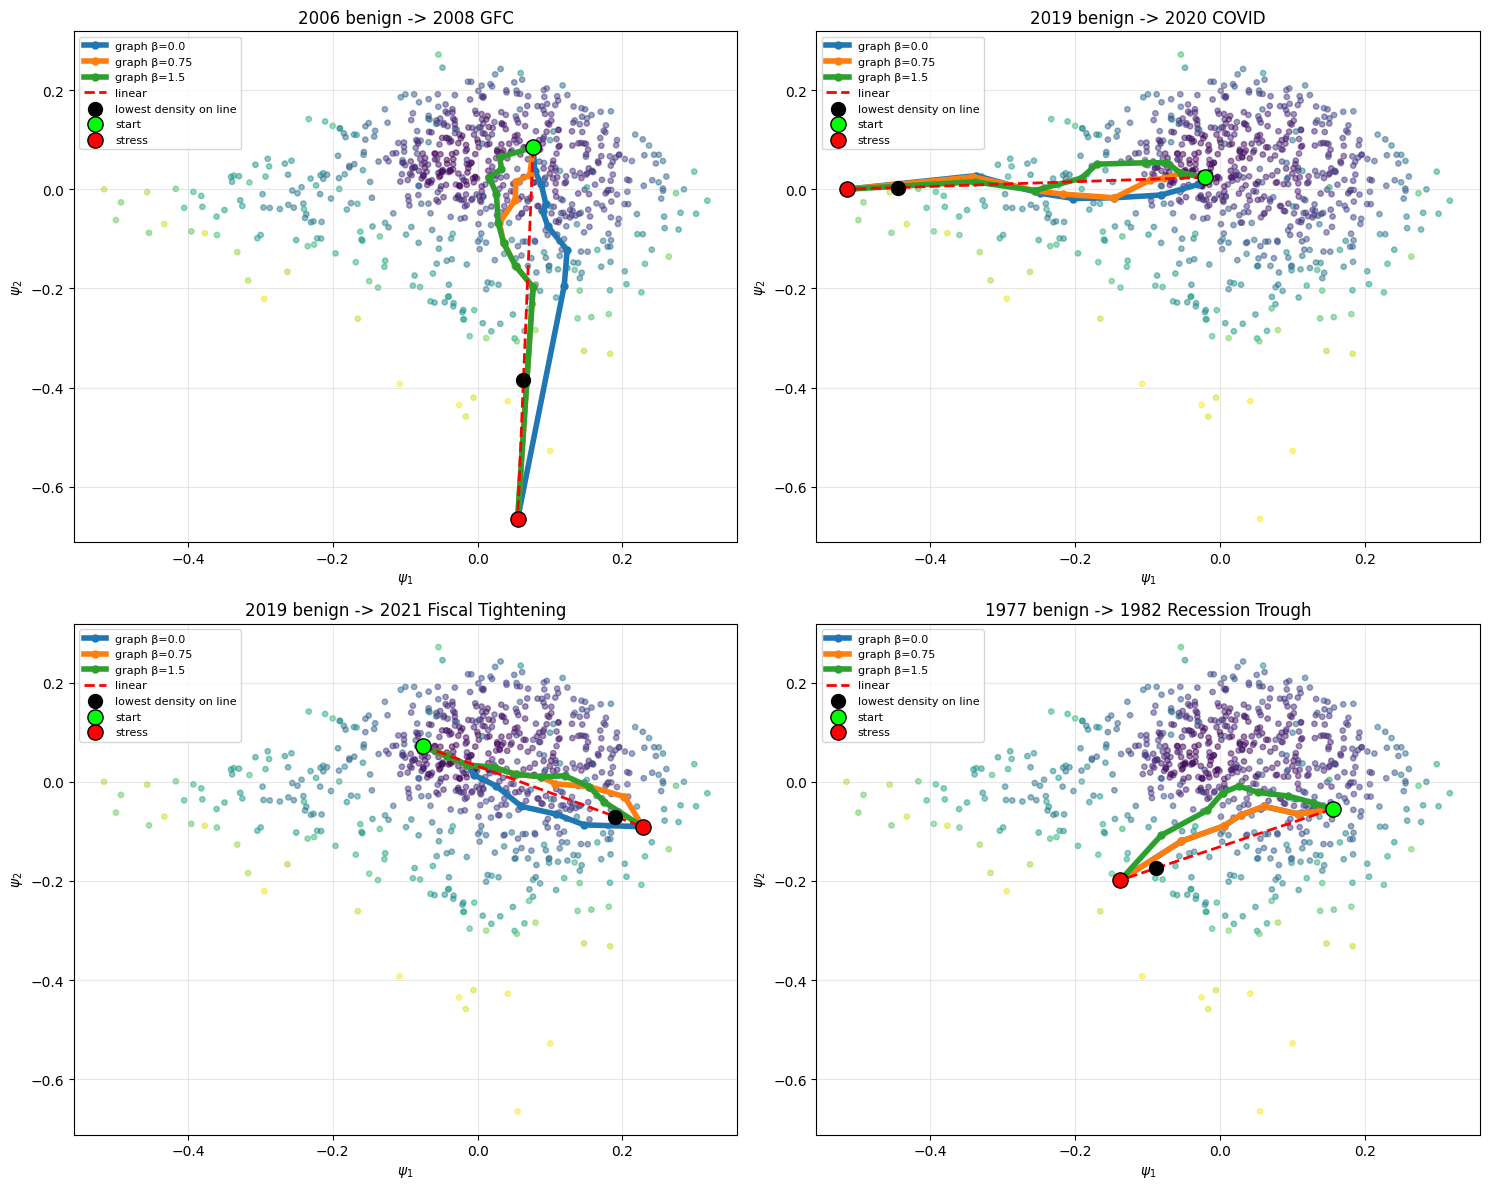

                            endpoints         path  min_rho_lin  mean_rho_lin  max_NNdist
              2006 benign -> 2008 GFC  graph β=0.0       0.1706        1.1336      0.0000
              2006 benign -> 2008 GFC graph β=0.75       0.3120        1.1213      0.0000
              2006 benign -> 2008 GFC  graph β=1.5       0.3120        1.3036      0.0000
              2006 benign -> 2008 GFC       linear       0.0028        0.3045      0.1127
            2019 benign -> 2020 COVID  graph β=0.0       0.1861        0.6669      0.0000
            2019 benign -> 2020 COVID graph β=0.75       0.2406        0.9343      0.0000
            2019 benign -> 2020 COVID  graph β=1.5       0.2591        0.9639      0.0000
            2019 benign -> 2020 COVID       linear       0.0692        0.4825      0.0435
2019 benign -> 2021 Fiscal Tightening  graph β=0.0       0.8514        1.6905      0.0000
2019 benign -> 2021 Fiscal Tightening graph β=0.75       0.9182        1.7466      0.0000
2019 benig

In [8]:
def nn_dist_to_cloud(pts):
    return np.array([np.min(np.linalg.norm(Psi - p, axis=1)) for p in pts])

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query = rho_query/scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def interior_min_mean(idx_path):
    interior = idx_path[1:-1] if len(idx_path) > 2 else idx_path
    return rho[interior].min(), rho[interior].mean()

def lin_interior_min_mean(s, e, h, scale, n=40):
    lin = np.linspace(Psi[s], Psi[e], n)[1:-1]
    rho_lin, _ = latent_density_at_points(lin, Psi, h, scale)
    return rho_lin.min(), rho_lin.mean(), nn_dist_to_cloud(lin).max(), np.argmin(rho_lin)

betas = [0.0, 0.75, 1.5]
summary = []
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, (name, (s, e)) in zip(axes.flatten(), pairs.items()):
    
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    
    path_lengths = []; paths = []
    for beta in betas:
        p = graph_path(A_dist_sym, beta, V, s, e)
        P = Psi[p]; path_lengths.append(len(P))
        ax.plot(P[:,0], P[:,1], marker="o", ms=5, label=f"graph β={beta}", linewidth=4)
        imin, imean = interior_min_mean(p)
        summary.append((name, f"graph β={beta}", imin, imean, nn_dist_to_cloud(P).max()))

    n_grid = int(np.mean(path_lengths))
    lin = np.linspace(Psi[s], Psi[e], n_grid)
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")
    
    llmin, llmean, lnn, min_idx = lin_interior_min_mean(s, e, h_dens, scale, n=n_grid)

    ax.scatter(*lin[min_idx+1, :2], c="k", s=100, zorder=5, label="lowest density on line")
    summary.append((name, "linear", llmin, llmean, lnn))
    
    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    ax.set_title(name); ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$"); ax.legend(fontsize=8)
    ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

res = pd.DataFrame(summary, columns=["endpoints","path", "min_rho_lin", "mean_rho_lin", "max_NNdist"])
print(res.round(4).to_string(index=False))


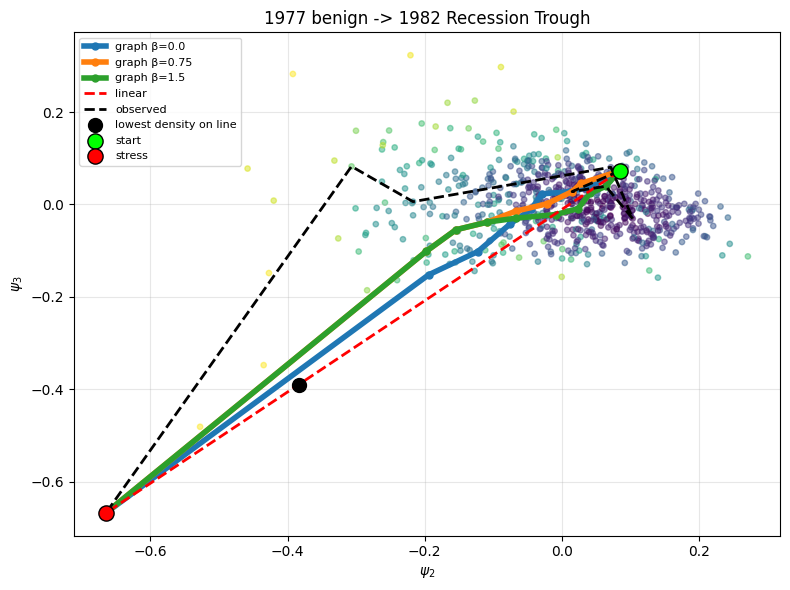

In [9]:
betas = [0.0, 0.75, 1.5]

fig, ax = plt.subplots(figsize=(8, 6))
s, e = pairs["2006 benign -> 2008 GFC"]

real_idx = np.linspace(s, e, 8).round().astype(int)
obs = Psi[real_idx]

ax.scatter(Psi[:,1], Psi[:,2], c=V, s=15, cmap="viridis", alpha=.5)

path_lengths = []
for beta in betas:
    p = graph_path(A_dist_sym, beta, V, s, e)
    P = Psi[p]; path_lengths.append(len(P))
    ax.plot(P[:,1], P[:,2], marker="o", ms=5, label=f"graph β={beta}", linewidth=4)
    imin, imean = interior_min_mean(p)

n_grid = int(np.mean(path_lengths))
lin = np.linspace(Psi[s], Psi[e], n_grid)
ax.plot(lin[:,1], lin[:,2], "r--", lw=2, label="linear")
ax.plot(obs[:,1], obs[:,2], "k--", lw=2, label="observed")

llmin, llmean, lnn, min_idx = lin_interior_min_mean(s, e, h_dens, scale, n=n_grid)

ax.scatter(lin[min_idx+1, 1], lin[min_idx+1, 2], c="k", s=100, zorder=5, label="lowest density on line")
ax.scatter(Psi[s,1], Psi[s, 2], c="lime", s=120, ec="k", zorder=5, label="start")
ax.scatter(Psi[e,1], Psi[e, 2], c="red", s=120, ec="k", zorder=5, label="stress")

ax.set_title(name); ax.set_xlabel(r"$\psi_2$")
ax.set_ylabel(r"$\psi_3$"); ax.legend(fontsize=8)
ax.grid(alpha=.3)

plt.tight_layout()
plt.show()


This plot shows clearly how the graph paths are seeking more dense regions.

I have a slight concern that the first point in the graph paths is in the more dense cluster whereas the linear path is evenly spaced out along the path. I suppose in the real economy, big jumps are observed anyway so this maybe isn't a big deal. I visualise the real path with the black dashed line.

# Figure 6
Density along each path

In [10]:
path_records = []

for event, (start_idx, end_idx) in pairs.items():

    # Standard graph path
    idx_graph = graph_path(A_dist_sym, beta=0.0, V=V, start=start_idx, end=end_idx)
    path_records.append({"event": event, "path_type": "ordinary graph", "coords": Psi[idx_graph],
                          "density": rho[idx_graph], "V": V[idx_graph], "Z_lift": Z[idx_graph], "node_indices": idx_graph})

    # Beta = 0.75 graph path
    idx_aware_075 = graph_path(A_dist_sym, beta=0.75, V=V, start=start_idx, end=end_idx)
    path_records.append({"event": event, "path_type": r"density-aware $\beta=0.75$", "coords": Psi[idx_aware_075], 
                         "density": rho[idx_aware_075], "V": V[idx_aware_075], "Z_lift": Z[idx_aware_075], "node_indices": idx_aware_075})

    # Beta = 1.5 graph path
    idx_aware_150 = graph_path(A_dist_sym, beta=1.5, V=V, start=start_idx, end=end_idx)
    path_records.append({"event": event, "path_type": r"density-aware $\beta=1.5$", "coords": Psi[idx_aware_150],
                         "density": rho[idx_aware_150], "V": V[idx_aware_150], "Z_lift": Z[idx_aware_150], "node_indices": idx_aware_150})

    # Linear lift using LNL
    n_grid = int(np.round(np.mean([len(idx_graph), len(idx_aware_075), len(idx_aware_150)])))
    gamma = linear_path(Psi, start_idx, end_idx, n_grid)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    Z_lin = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    path_records.append({"event": event, "path_type": "linear", "coords": gamma, "density": rho_lin, "V": V_lin, "Z_lift": Z_lin})

    # Observed path
    real_idxs = np.linspace(start_idx, end_idx, n_grid).round().astype(int)
    real_path = Z[real_idxs]
    path_records.append({"event": event, "path_type": "observed", "coords": np.nan, "density": np.nan, "V": np.nan, "Z_lift": real_path})

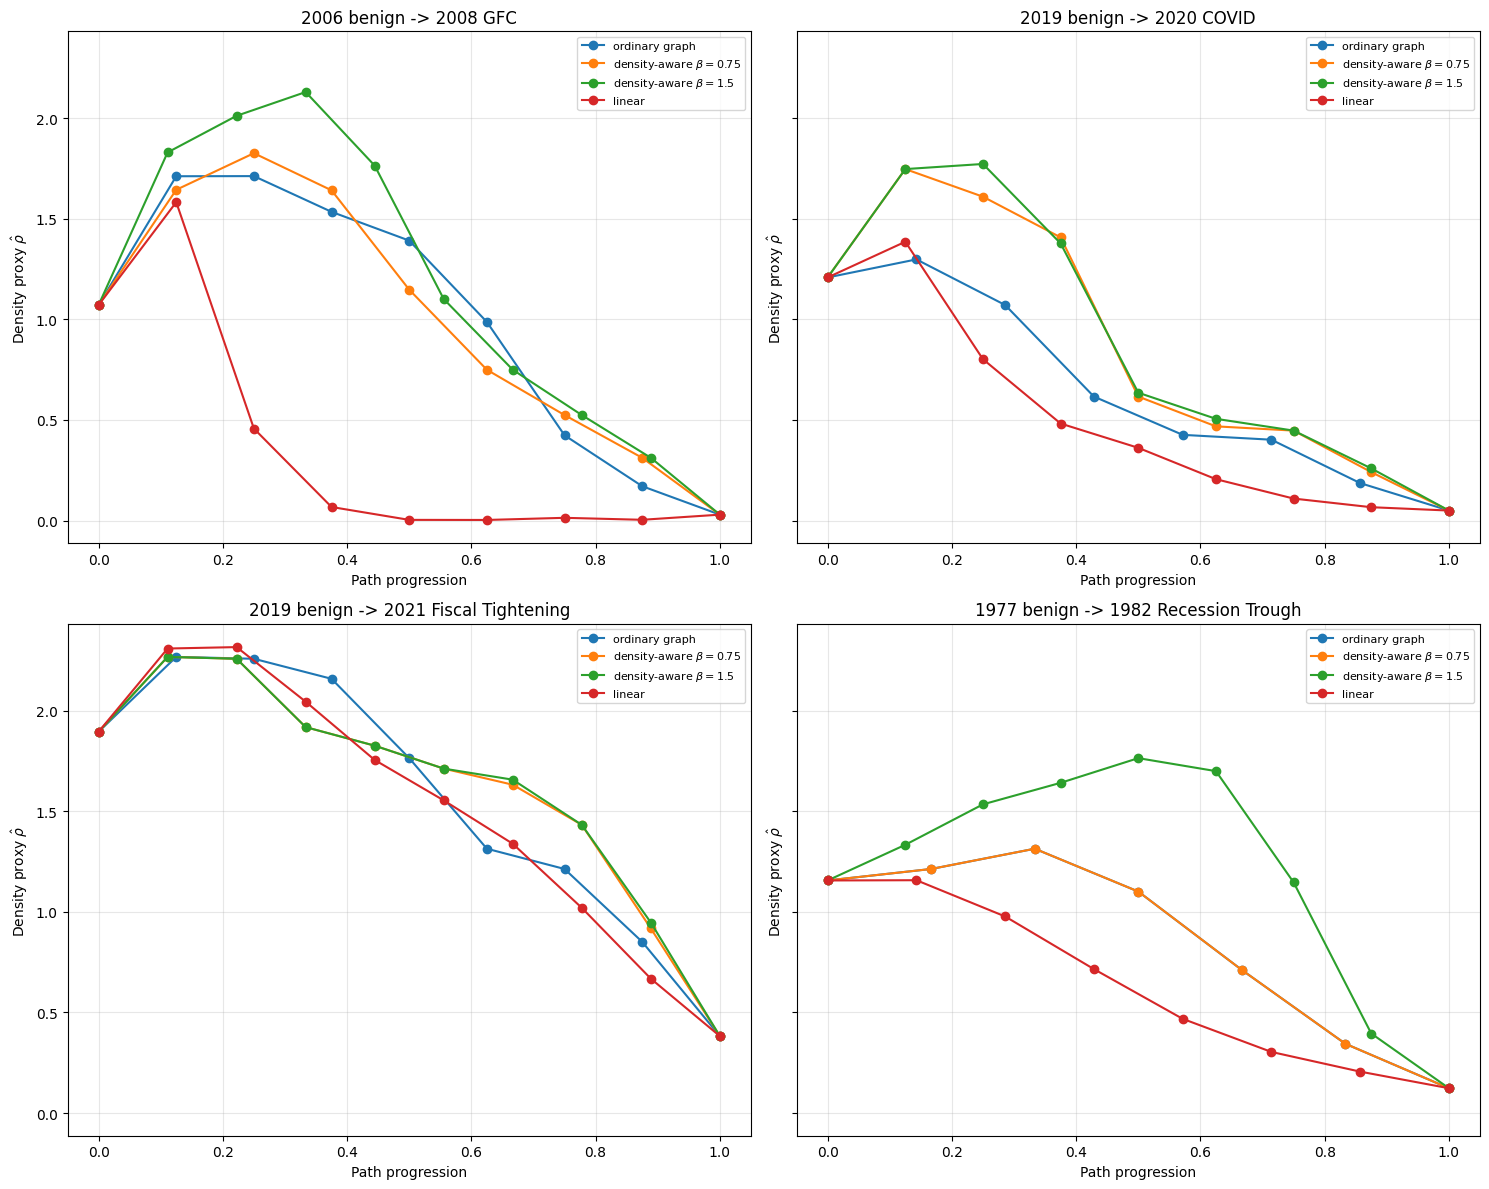

In [11]:
events = list(pairs.keys())

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharey=True)

for ax, event in zip(axes.flatten(), events):
    event_records = [rec for rec in path_records if rec["event"] == event and rec["path_type"] != "observed"]

    for rec in event_records:
        density = rec["density"]
        x = np.linspace(0, 1, len(density))
        ax.plot(x, density, marker="o", label=rec["path_type"])

    ax.set_title(event); ax.set_xlabel("Path progression")
    ax.set_ylabel(r"Density proxy $\hat{\rho}$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Clearly the linear path performs the worse (in terms of path density) for the `2006 -> 2008 GFC` scenario, and the best in the `2019 -> 2021 Fiscal Tightening` scenario. I will examine a selection of lifted macroeconomic variables for both of these paths.

# Figure 7
Secetion of macroeconomic variables plotted along each path

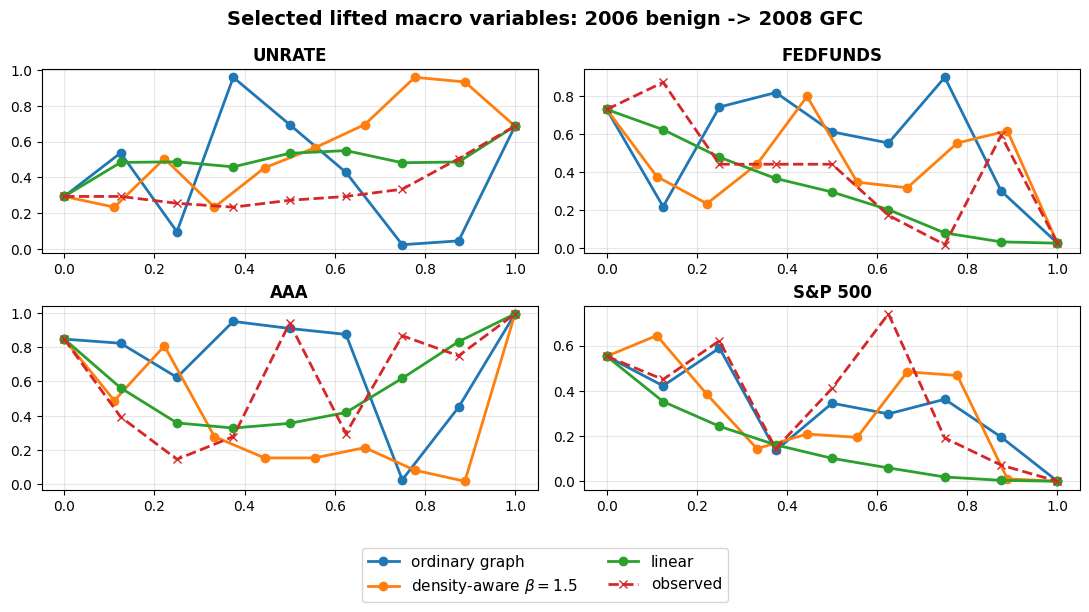

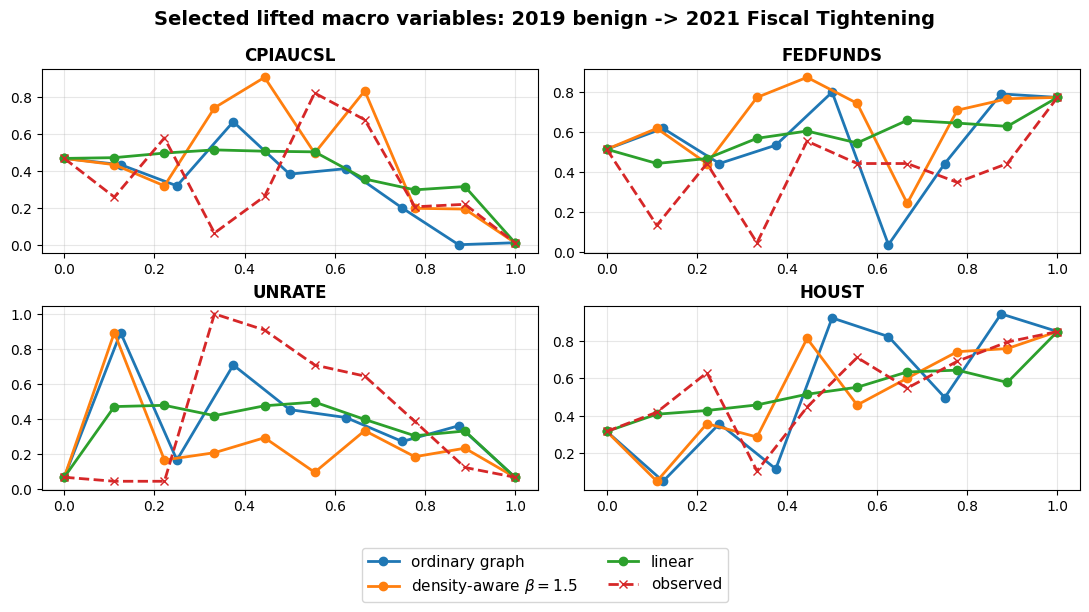

In [12]:
event_variables = {"2006 benign -> 2008 GFC": ["UNRATE", "FEDFUNDS", "AAA", "S&P 500"],
                   "2019 benign -> 2021 Fiscal Tightening": ["CPIAUCSL", "FEDFUNDS", "UNRATE", "HOUST"]}

for event, selected_vars in event_variables.items():
    # list of different paths for a certain event
    event_records = [rec for rec in path_records if rec["event"] == event]

    selected_idxs = [variables.get_loc(v) for v in selected_vars]
    n_vars = len(selected_vars); n_cols = 2
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 6), squeeze=False)
    axes_flat = axes.flatten()

    for path in event_records:
        path_type = path["path_type"]
        if path_type == r"density-aware $\beta=0.75$":
            continue

        lifted_path = path["Z_lift"]
        x = np.linspace(0, 1, len(lifted_path))

        for i, var_idx in enumerate(selected_idxs):
            ax = axes_flat[i]
            if path_type == "observed":
                ax.plot(x, lifted_path[:, var_idx], marker="x", linestyle="--", linewidth=2, label=path_type)
            else:
                ax.plot(x, lifted_path[:, var_idx], marker="o", linewidth=2, label=path_type)

            ax.set_title(selected_vars[i], fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3)

    for j in range(n_vars, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(f"Selected lifted macro variables: {event}", fontsize=14, fontweight="bold")

    plt.tight_layout(); plt.subplots_adjust(bottom=0.18)
    plt.show()

We do see the linear path is obviously quite smooth while the graph paths and the observed paths are quite noisy. This represents the graph paths and observed paths taking a non-linear path to remain on the manifold, while the linear paths cuts straight through.

# Figure 8
Sensitivity of minimum density to $\beta$

In [13]:
path_records = []
betas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

for event, (start_idx, end_idx) in pairs.items():
    for beta in betas:
        idx_graph = graph_path(A_dist_sym, beta=beta, V=V, start=start_idx, end=end_idx)
        if len(idx_graph) > 2:
            interior_density = rho[idx_graph][1:-1]
        else:
            interior_density = rho[idx_graph]
        path_records.append({"event": event, "beta": beta, "min_density": interior_density.min(), "mean_density": interior_density.mean()})

beta_df = pd.DataFrame(path_records)


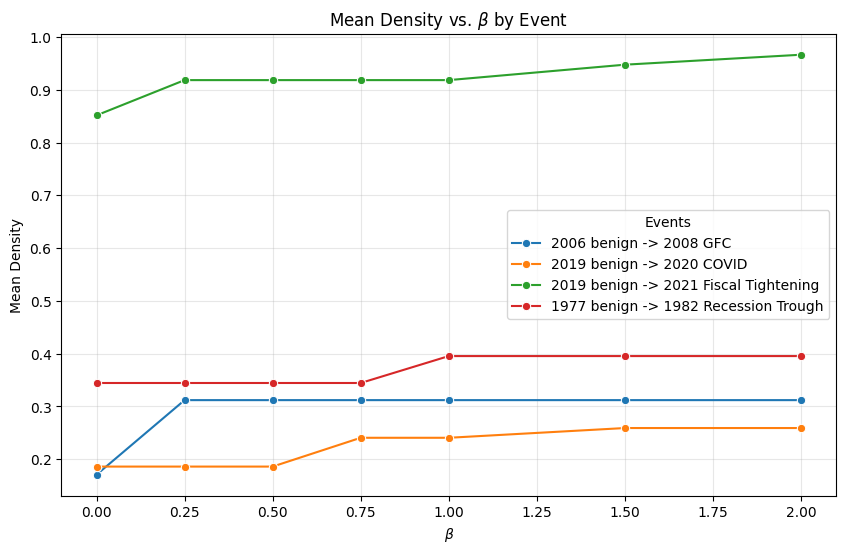

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=beta_df, x='beta', y='min_density', hue='event', marker='o', palette='tab10')

plt.xlabel(r'$\beta$'); plt.ylabel('Mean Density')
plt.title(r'Mean Density vs. $\beta$ by Event')
plt.legend(title='Events'); plt.grid(alpha=0.3)
plt.show()

# Figure 9
Sensitivity of path to $k$

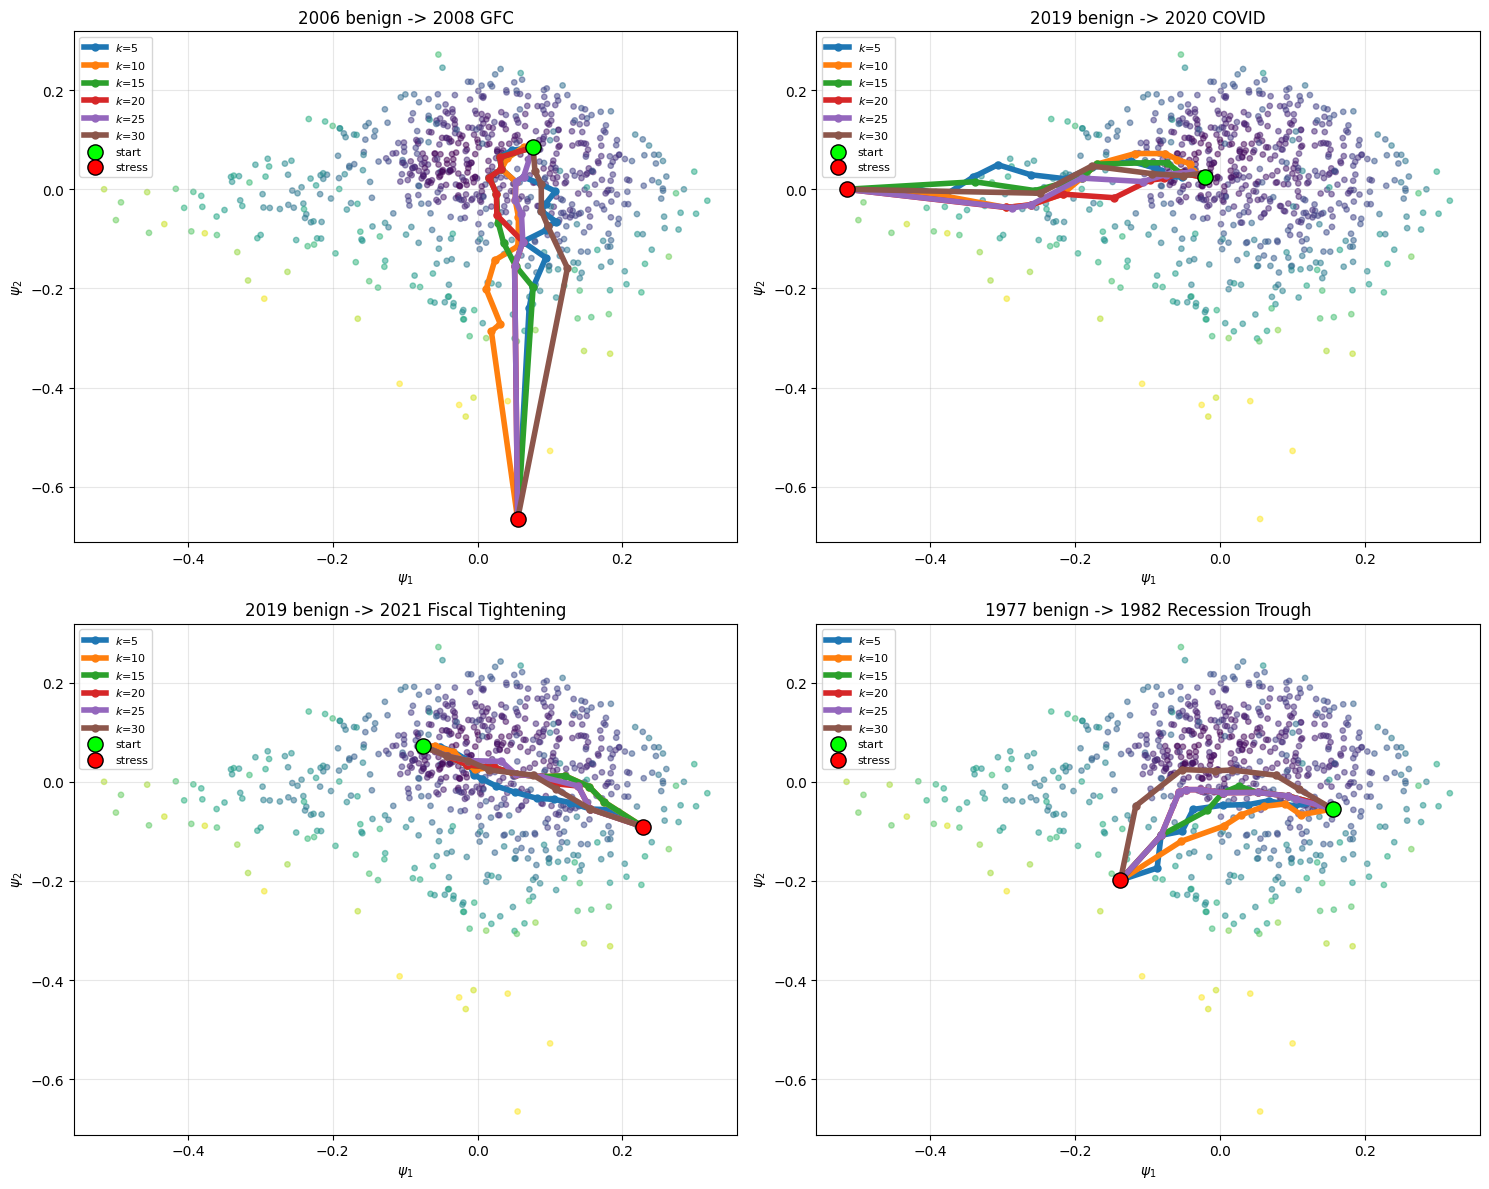

 k                                 event  number_points  interior_minimum_density  interior_mean_density  latent_path_length  density_weighted_cost  smoothness  direction_change
 5               2006 benign -> 2008 GFC             18                    0.1158                 1.2115              1.2415                48.6152      0.3636           16.6775
10               2006 benign -> 2008 GFC             13                    0.2093                 1.1677              1.2020                33.6883      0.4833            5.9251
15               2006 benign -> 2008 GFC             10                    0.3120                 1.3036              1.1211                25.4583      0.4589            2.8580
20               2006 benign -> 2008 GFC              9                    0.3248                 1.3928              1.1035                24.9362      0.4692            3.6526
25               2006 benign -> 2008 GFC              8                    0.3248                 1.2434      

In [26]:
def latent_path_length(coords):
    diffs = np.diff(coords, axis=0)
    return np.linalg.norm(diffs, axis=1).sum()

def path_smoothness(coords):
    if len(coords) < 3:
        return 0.0
    second_diff = coords[2:] - 2 * coords[1:-1] + coords[:-2]
    return np.sum(np.linalg.norm(second_diff, axis=1) ** 2)

def density_weighted_cost(coords, V_path, beta):
    diffs = np.diff(coords, axis=0)
    edge_lengths = np.linalg.norm(diffs, axis=1)
    V_mid = 0.5 * (V_path[:-1] + V_path[1:])
    return np.sum(edge_lengths * np.exp(beta * V_mid))

def direction_change(coords):
    d = np.diff(coords, axis=0)
    u = d / np.linalg.norm(d, axis=1)[:, None]
    return np.sum( np.linalg.norm(np.diff(u, axis=0), axis=1)**2 )



fig, axes = plt.subplots(2, 2, figsize=(15, 12))
rows = []

for ax, (name, (s, e)) in zip(axes.flatten(), pairs.items()):
    
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    
    ks = [5, 10, 15, 20, 25, 30]
    for k in ks:
        A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
        A_dist_sym = A_dist.maximum(A_dist.T)
        p = graph_path(A_dist_sym, BETA, V, s, e)
        P = Psi[p]; V_path = V[p]
        ax.plot(P[:,0], P[:,1], marker="o", ms=5, label=f"$k$={k}", linewidth=4)
        imin, imean = interior_min_mean(p)

        rows.append({
                "k": k,
                "event": name,
                "number_points": P.shape[0],
                "interior_minimum_density": imin,
                "interior_mean_density": imean,
                "latent_path_length": latent_path_length(P),
                "density_weighted_cost": density_weighted_cost(P, V_path, beta=BETA),
                "smoothness": path_smoothness(P),
                "direction_change": direction_change(P)
            })

    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    ax.set_title(name); ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

res = pd.DataFrame(rows)
print(res.round(4).to_string(index=False))


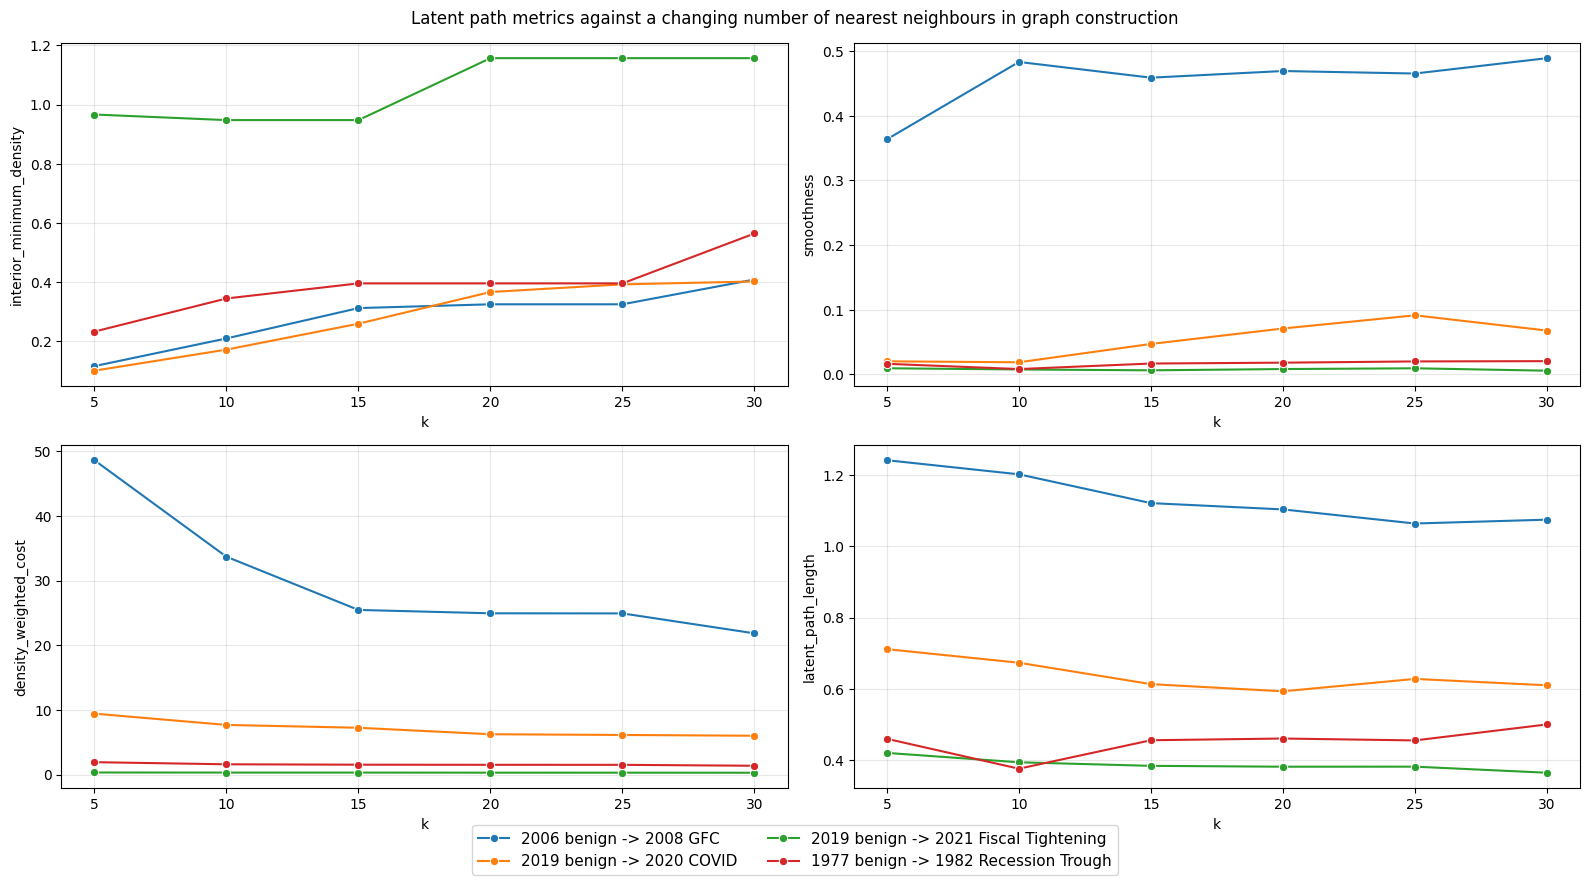

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['interior_minimum_density', 'smoothness', 'density_weighted_cost', 'latent_path_length']

for i, metric in enumerate(metrics):
    sns.lineplot(data=res, x='k', y=metric, hue='event', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

These all look pretty stable.

- `interior_minimum_density` is increasing, probably because as more neighbours are introduced, the path is pulled closser towards the highly-dense region of the latent space. This suggests that increasing $k$ results in more realsitic paths, but from Phase 5 we see that past $k=22$ the RMSE error of the LNL lift starts to increase.
- `smoothness` suggests that as $k$ increases the paths become more jagged (less smooth), this is <span style="color:red">not what I would expect</span>, nor is it what I see in the plots (apart from maybe `1977 benign -> 1982 Recession`). The lower $k$ paths for `2006 benign -> 2008 GFC` look far more jagged than the high $k$ pahts, but this is not reflected in the smoothness score. Maybe I am misunderstanding the point of the smoothness score; from my earlier understanding, a higher smoothness means more curvature. Increasing $k$ means that each that for a given point on a path, there are more options to choose the next point. I would have expected decreasing $k$ means that paths are forced to take suboptimal routes to neighbours that are near but not in the right direction. Maybe the fact that the low $k$ paths are made up of lots of smaller jumps means that the smoothness penalty decreases, because each second difference is squared, so small differences result in a disproportionally small sum of squares. Is there a way to normalise for the length of the jumps, or is this correctly capturing the "smoothness" already?

- `density_weighted_cost` reduces as $k$ increases. This makes sense because there are now more choices for the shortest path algorithm to make, i.e. it is less restricted. Increasing $k$ can't increase the cost because that implies that there is a path that is no longer available.

- `latent_path_length` decreases for all of the paths apart from `1977 benign -> 1982 Recession Trough`. This is what I expected, but my explanation only makes sense if the paths are more smooth with an increasing $k$, which is apparently not the case. I need to understand the 'smoothness' metric better.

#### New metric to capture the jaggedness of the path

I now take a direction change score:

$$d_\ell = \gamma_{\ell+1}-\gamma_\ell, \quad u_\ell = \frac{d_\ell}{\|d_\ell\|},$$
then
$$ S_\text{angle} = \sum_\ell\|u_{\ell+1}-u_\ell\|^2$$

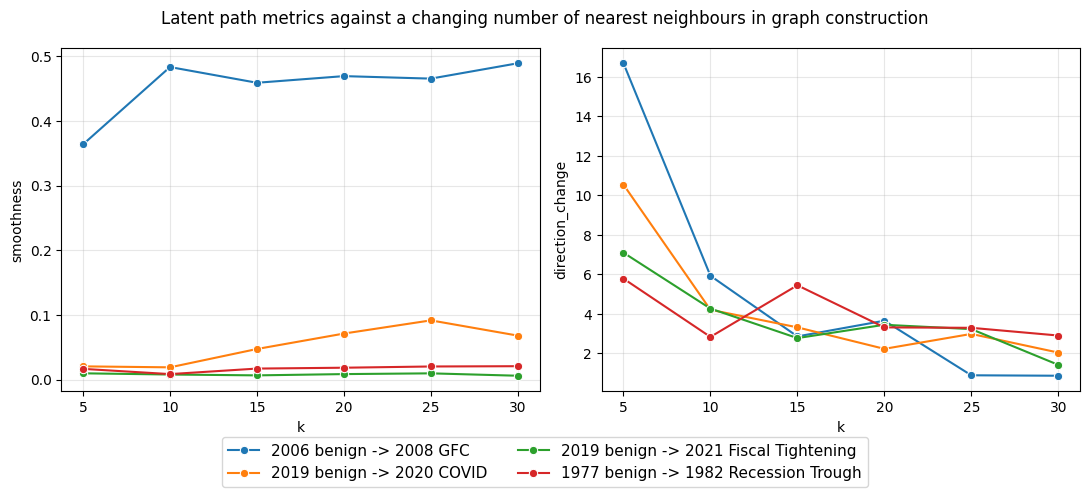

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['smoothness', 'direction_change']

for i, metric in enumerate(metrics):
    sns.lineplot(data=res, x='k', y=metric, hue='event', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

This is a lot more inline with what I see in the plots of the paths.